<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers openpyxl datasets langchain-community ragatouille umap-learn faiss-gpu-cu11==1.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of requests[socks] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/4

In [ ]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

/tmp/ipython-input-3214063602.py:16: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel
W1124 07:50:41.227000 835 torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


## Загрузка данных (4 балла)

In [ ]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=2dfc3433-ad2c-43fc-a34a-7af06d2b3dbb
To: /content/file.csv
100%|██████████| 672M/672M [00:07<00:00, 90.1MB/s]


In [ ]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


## Общее изучение данных

Посмотрим на описания и названия памятников

In [ ]:
set(data['description'])

{nan,
 'Автозаводский парк',
 'Армянская церковь в г. Владимир России',
 'Архитектурный ансамбль в Ярославле',
 'Башня в Ярославле',
 'Белокаменные памятники Владимира и Суздаля',
 'Беседка на Волжской набережной',
 'Библиотека в Екатеринбурге',
 'Благовещенско-Вознесенский приход',
 'Блиновский пассаж',
 'Богородице-Рождественский монастырь (Владимир)',
 'Бутусовский посёлок',
 'Вечный огонь (Ярославль)',
 'Владимиро-Суздальский музей-заповедник',
 'Владимирская духовная семинария',
 'Владимирская церковь на Божедомке',
 'Владимирский авиамеханический колледж',
 'Владимирский государственный гуманитарный университет',
 'Владимирский кремль',
 'Владимирский планетарий',
 'Владимирское духовное училище',
 'Вознесенско-Сретенский приход',
 'Воинское мемориальное кладбище (Ярославль)',
 'Воскресенская церковь (Нижний Новгород)',
 'Второй Дом Советов (Екатеринбург)',
 'ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва',
 'Городской сад в Ярославле',
 'Государстве

In [ ]:
len(set(data['Name']))

387

Если честно, то большая часть из приведенных названий соответсвует историческим местам, либо потенциальным туристическим местам. Кажется возможной фильтрация руками т.к. всего

In [ ]:
len(set(data['description']))

246

246 описаний мест приведено в данных. Из них, вероятно, есть повторяющиеся, но с разными названиями (т.к. названий 387)

При этом есть сложные примеры. В частности, "Общежитие института инженеров водного транспорта с кинотеатром «Рекорд»" может показаться не туристическим местом, но на самом деле - это памятник градостроительства и архитектуры регионального значения в историческом центре Нижнего Новгорода. Построен в 1934—1938 годах, по проекту, выполненному в мастерской горьковского архитектора

Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [ ]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

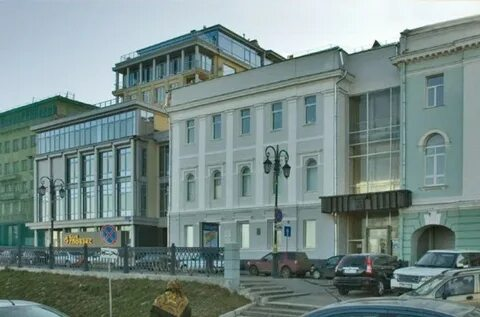

In [ ]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

# Фильтрация данных
## Фильтрация плохих сэмплов статистикой

Попробуем удалить совсем мусорные данные

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Объединяем все текстовые поля
data['combined_text'] = (
    data['Name'].fillna('') + ' ' +
    data['City'].fillna('') + ' ' +
    data['description'].fillna('') + ' ' +
    data['en_txt'].fillna('')
)

In [ ]:
corpus = data['combined_text'].tolist()

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,        # топ-1000 слов
    stop_words='english',     # убираем стоп-слова
    ngram_range=(1, 2)        # учитываем 1-2 слова
)
tfidf_matrix = vectorizer.fit_transform(corpus)

In [ ]:
# Получаем средний TF-IDF score для каждого слова
mean_tfidf_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()

# Создаем DataFrame
tfidf_df = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'mean_tfidf': mean_tfidf_scores
})

# Сортируем по TF-IDF score
tfidf_df = tfidf_df.sort_values('mean_tfidf', ascending=False)

print("Слова с самым высоким TF-IDF (важные/редкие):")
print(tfidf_df.head(20))

print("\nСлова с самым низким TF-IDF (частые/неважные):")
print(tfidf_df.tail(20))

Слова с самым высоким TF-IDF (важные/редкие):
                 word  mean_tfidf
293          building    0.029707
58             arafed    0.029405
4898        ярославль    0.029054
2514         владимир    0.026019
2984     екатеринбург    0.022672
3831         новгород    0.022364
3807  нижний новгород    0.022364
3806           нижний    0.022364
4737          церковь    0.020969
2092             view    0.019396
1033            large    0.019164
2897              дом    0.018891
4675             храм    0.018266
3662            музей    0.017856
4868        ярославле    0.017714
2179            white    0.017536
3045    екатеринбурге    0.017508
537             clock    0.017357
109       arafed view    0.017096
462            church    0.016710

Слова с самым низким TF-IDF (частые/неважные):
                   word  mean_tfidf
902         group young    0.000079
2131               walk    0.000079
3593        мест yellow    0.000078
2756     гимназии large    0.000078
4563  универ

In [ ]:
# Создаем CountVectorizer
count_vectorizer = CountVectorizer(stop_words='english', max_features=2000)
count_matrix = count_vectorizer.fit_transform(corpus)

# Получаем словарь (features)
feature_names = count_vectorizer.get_feature_names_out()

# Суммируем частоты по всем документам
word_counts = np.array(count_matrix.sum(axis=0)).flatten()

# Создаем DataFrame для анализа
word_freq_df = pd.DataFrame({
    'word': feature_names,
    'count': word_counts
})

# Сортируем по частоте
word_freq_df = word_freq_df.sort_values('count', ascending=False)

print("Самые частые слова:")
print(word_freq_df.head(20))

print("\nСамые редкие слова:")
print(word_freq_df.tail(20))

Самые частые слова:
               word  count
205        building   6383
75           arafed   6215
1994      ярославль   5365
1656         нижний   4000
1666       новгород   4000
1276       владимир   3799
1406   екатеринбург   3604
1126           view   2910
587           large   2868
1960        церковь   2809
1152          white   2464
1387            дом   2457
282           clock   2384
273          church   2333
1622          музей   2318
1945           храм   2259
1408  екатеринбурге   2190
1993      ярославле   2101
1078          tower   2009
495           green   1918

Самые редкие слова:
                     word  count
46                 amplis      1
87                 arafia      1
1                   100th      1
1847           сралнннннн      1
55                antekka      1
32                  agate      1
49                  anexo      1
47              amusement      1
91               arafiski      1
45             amethorate      1
22                     4k    

Как видно, действительно есть мусорные слова. Можно попытаться выделить по ним плохие примеры из данных.

In [ ]:
word_freq_df[word_freq_df['count']<3]

,word,count
437,figures,2
566,kinds,2
585,lap,2
582,land,2
301,colors,2
...,...,...
59,aom,1
10,1930s,1
79,araffaeration,1
1758,прррмомоннннннннннн,1


In [ ]:
word_freq_df[word_freq_df['count']<2]

,word,count
69,arabakexplus,1
101,architecture,1
26,accordion,1
64,applauding,1
76,arafexibular,1
40,alley,1
74,arafective,1
3,123,1
72,arafactation,1
65,apple,1


Слова встречающиеся реже 2 раз являются галлюцинацией, но даже тут есть адекватные слова (agate, america и т.д.). попробуем составить список плохих слов

In [ ]:
bad_words = ['arabakexplus','arafexibular','arafective','arafactation','apttapa','arafpop','сралнннннн','antekka','aoa','aom','araffaeration','прррмомоннннннннннн']

In [ ]:
import re

# Создаем regex паттерн
pattern = '|'.join([re.escape(word) for word in bad_words])

# Фильтруем
df_clean = data[~data['combined_text'].str.contains(pattern, case=False, na=False)].copy()

print(f"Было: {len(data)} записей")
print(f"Стало: {len(df_clean)} записей")
print(f"Удалено: {len(data) - len(df_clean)} записей")

Было: 14634 записей
Стало: 14624 записей
Удалено: 10 записей


уменьшить датасет это не помогло, но зато отбросили совсем сомнительные данные

Датасет исходя из этого не получилось уменьшить, впрочем совсем плохие данные мы отбросили.

## Отбор туристическиих мест и значимых описаний с фото с помощью LLM

Попробуем экспериментальный вариант. Попробуем применить LLM для определения, является ли объект историческим или нет. Будем передавать только description, т.к. их всего 246, LLM спокойно это сделает. Это позволит выделить точно туристические и точно не туристические места. Для защиты от галлюцинаций попросим LLM в случае неуверенности возвращать конкретный ответ.

In [ ]:
places = list(set(df_clean['description']))

In [ ]:
from openai import OpenAI


client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)


def classify_with_llm(description):
    prompt = f"""
    Классифицируй является ли это описание туристическим местом.
    Верни ТОЛЬКО ОДНО ЧИСЛО: 1, 0 или -1

    Правила:
    - 1 = точно туристическое место (памятник, музей, исторический объект)
    - 0 = не уверен, нужно проверить вручную
    - -1 = точно не туристическое место (личное фото, мем, реклама и т.д.)

    ОТВЕЧАЙ ТОЛЬКО ЧИСЛОМ!

    Описание: {description}

    Ответ:"""

    chat_result = client.chat.completions.create(
    messages=[{"role": "user", "content": prompt}],
    model="google/gemini-2.5-flash-lite-preview-09-2025",
    max_tokens=3)

    response = chat_result.choices[0].message
    return response.content

In [ ]:
answers = []
for i in places:
  answers.append(classify_with_llm(i))

In [ ]:
answers

['1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '-1',
 '0',
 '0',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '-1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '-1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 

Сохраним ответ LLM в pandas dataframe и локально чтобы не пересчитывать всё это позже

In [ ]:
# Функция для извлечения класса из ответа LLM
def extract_class_from_answer(answer):
    """Извлекает число класса из ответа LLM"""
    import re
    if pd.isna(answer):
        return 0
    numbers = re.findall(r'-?\d+', str(answer))
    if numbers:
        classification = int(numbers[0])
        if classification in [-1, 0, 1]:
            return classification
    return 0  # по умолчанию, если не удалось распарсить

df_results = pd.DataFrame({
    'description': places,  # исходные описания
    'llm_answer': [extract_class_from_answer(answer) for answer in answers],
})

In [ ]:
df_results

,description,llm_answer
0,Ярославский государственный цирк,1
1,Храм Всемилостивого Спаса (Нижний Новгород),1
2,Сормовский парк,1
3,предприятие в Екатеринбурге,0
4,"православный храм во Владимире, памятник белок...",1
...,...,...
241,улица в Екатеринбурге,0
242,Нижегородская соборная мечеть,1
243,Здание городской думы,1
244,образовательное учреждение в Ярославле,0


ответ везде укладывается в наш формат

In [ ]:
set(df_results['llm_answer'])

{-1, 0, 1}

Сохранение

In [ ]:
df_results.to_csv('tourism_classification_results.csv', index=False, encoding='utf-8')

Загрузка

In [ ]:
df_results = pd.read_csv('tourism_classification_results.csv')

Посмотрим где модель уверенно сказала "нет"

In [ ]:
list(df_results[df_results['llm_answer']==-1]['description'])

['ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва',
 nan,
 'белорусский поэт, публицист, литературовед, переводчик.']

Все выглядит достаточно логичным. При детальном изучении его ответов можно понять, что под "белорусский поэт, публицист, литературовед, переводчик." подразумевается памятник, но это не размечено даже в названии. Больница же была открыта в 1781 году и также является историческим местом.

Вот так вот сложно с данными...

Список ниже требуется проставить вручную :(

В целом понятно почему LLM была не уверена

In [ ]:
df_results[df_results['llm_answer']==0]

,description,llm_answer
3,предприятие в Екатеринбурге,0
9,Дом Виноградовых,0
10,комплекс зданий в стиле конструктивизма,0
27,Владимирский государственный гуманитарный унив...,0
28,бывшее название университета в Екатеринбурге,0
30,Общежитие института инженеров водного транспор...,0
42,сооружение в Екатеринбурге,0
48,Здание Удельной конторы,0
55,Дом контор,0
69,Блиновский пассаж,0


In [ ]:
doubt = list(df_results[df_results['llm_answer']==0]['description'])
doubt

['предприятие в Екатеринбурге',
 'Дом Виноградовых',
 'комплекс зданий в стиле конструктивизма',
 'Владимирский государственный гуманитарный университет',
 'бывшее название университета в Екатеринбурге',
 'Общежитие института инженеров водного транспорта с кинотеатром «Рекорд»',
 'сооружение в Екатеринбурге',
 'Здание Удельной конторы',
 'Дом контор',
 'Блиновский пассаж',
 'Владимирский авиамеханический колледж',
 'Комплекс штаба военного округа',
 'профессиональное учебное заведение Екатеринбурга',
 'кладбище в Ярославле',
 'Бутусовский посёлок',
 'учебное заведение в Екатеринбурге',
 'здание в Екатеринбурге',
 'Школа № 33 имени Карла Маркса',
 'чебное заведение среднего профессионального образования в Нижнем Новгороде, готовящее специалистов водного транспорта.С 2005 года — филиал Волжской государственной академии водного транспорта, которая сейчас называется ВГУВТ.',
 'высшее учебное заведение в Екатеринбурге',
 'административное здание в Нижнем Новгороде, Россия',
 'здание в Желез

In [ ]:
hands_class = [-1,1,1,-1,-1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

In [ ]:
list(df_results[df_results['llm_answer']==-1]['description'])

['ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва',
 nan,
 'белорусский поэт, публицист, литературовед, переводчик.']

In [ ]:
descr = list(df_results['description'])
llm_ans = list(df_results['llm_answer'])

In [ ]:
places_classes = {}

for i in range(len(descr)):
  places_classes[descr[i]] = llm_ans[i]

for i in range(len(doubt)):
  places_classes[doubt[i]] = hands_class[i]

places_classes['ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва'] = 1
places_classes['белорусский поэт, публицист, литературовед, переводчик.'] = 1

In [ ]:
def get_final_classification(name):
  return places_classes[name]

In [ ]:
df_results['final_class'] = df_results['description'].apply(get_final_classification)

In [ ]:
df_results

,description,llm_answer,final_class
0,Ярославский государственный цирк,1,1
1,Храм Всемилостивого Спаса (Нижний Новгород),1,1
2,Сормовский парк,1,1
3,предприятие в Екатеринбурге,0,-1
4,"православный храм во Владимире, памятник белок...",1,1
...,...,...,...
241,улица в Екатеринбурге,0,1
242,Нижегородская соборная мечеть,1,1
243,Здание городской думы,1,1
244,образовательное учреждение в Ярославле,0,1


In [ ]:
df_results.to_csv('tourism_classification_results_final.csv', index=False, encoding='utf-8')

In [ ]:
# Объединяем и фильтруем
merged_data = data.merge(df_results[['description', 'final_class']], on='description', how='left')
tourism_data = merged_data[merged_data['final_class'] == 1].copy()

# Удаляем временную колонку
tourism_data = tourism_data.drop('final_class', axis=1)

print(f"Отфильтровано туристических мест: {len(tourism_data)}")

Отфильтровано туристических мест: 11994


Теперь мы отбросили места, которые считаем не туристическими и мусорные данные. далее необходимо сгруппировать места и описания. При этом нужно отделить некорректные описания от корректных

In [ ]:
set(tourism_data['en_txt'])

{'there is a large brick tower with a flag on top of it',
 'arafed white church with a steeple and a green field',
 'arafed image of a church with a clock tower and a sky background',
 'arafed white building with green roof and towers with a cross on top',
 'arafed yellow house with a black roof and a white fence',
 'there are two headstones of people who are buried in the grass',
 'a close up of a statue of a man with a coat on a pedestal in front of a',
 'arafed building with a clock tower and a blue sky',
 'arafed wooden church with green roof and steeple and snow covered ground',
 'arafed view of a large building with a clock tower in the middle of it',
 'arafed statue of a man in a green hat in a city square',
 'there is a room with a piano, a chair, a table and a clock',
 'there are many arches that are in the middle of a walkway',
 'a picture of a man in military clothing talking on a phone',
 'snowy street with a row of buildings and a car parked on the side',
 'a black and whi

arafed  - вроде как артефакт модели BLIP 2. Сами описания не ужасные, но слово точно лишнее. Нужно его удалить чтобы не ломать эмбеддинги. В остальном описания кажутся нормальными

In [ ]:
tourism_data['en_txt'] = tourism_data['en_txt'].str.replace(
    'arafed',
    '',
    case=False,
    regex=False
)

Сохраним очищенные данные

In [ ]:
tourism_data.to_csv('Cleaned_Data.csv', index=False, encoding='utf-8')

In [ ]:
Cleaned_Data = pd.read_csv('Cleaned_Data.csv')

In [ ]:
len(set(Cleaned_Data['en_txt']))

8070

Видим что по итогу осталось всего 8070 уникальных строк описаний. Скорее всего многие описания повторяются между туристическими местами. Причем из обсуждения в ТГ уже известно, что часть из них не относятся к туристическим местам

Можно применить "прямолинейный" метод фильтрации. Попросим LLM определить содержит ли описание полезную информацию о туристическом месте или же нет. В промпте при этом важно указать что речь как правило идет о здании

In [ ]:
txt = list(set(Cleaned_Data['en_txt']))[0:10]

In [ ]:
from openai import OpenAI


client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)


def classify_with_llm(description):
    prompt = f"""
    Классифицируй является ли описание туристического места полезным.
    Верни ТОЛЬКО ОДНО ЧИСЛО: 1, 0

    Правила:
    - 1 = Информация полезна (памятник, музей, исторический объект)
    - 0 = Информация не соответствует туристическому месту, либо не полезна (личное фото, мем, реклама и т.д.)

    ОТВЕЧАЙ ТОЛЬКО ЧИСЛОМ!

    Описание: {description}

    Ответ:"""

    chat_result = client.chat.completions.create(
    messages=[{"role": "user", "content": prompt}],
    model="google/gemini-2.5-flash-lite-preview-09-2025",
    max_tokens=3)

    response = chat_result.choices[0].message
    return response.content

In [ ]:
from tqdm import tqdm

answers = []
for i in tqdm(txt):
  answers.append(classify_with_llm(i))

100%|██████████| 10/10 [00:03<00:00,  3.01it/s]


In [ ]:
txt[7]

' statue of a man holding a flag in front of a sunset'

In [ ]:
answers

['1', '1', '0', '1', '1', '0', '0', '1', '1', '1']

In [ ]:
txt = list(set(Cleaned_Data['en_txt']))

In [ ]:
answers = []
for i in tqdm(txt):
  answers.append(classify_with_llm(i))

100%|██████████| 8070/8070 [42:27<00:00,  3.17it/s]


In [ ]:
answers

['1',
 '1',
 '0',
 '1',
 '1',
 '0',
 '0',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '0',
 '1',
 '0',
 '0',
 '0',
 '0',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '0',
 '1',
 '1',
 '0',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '0',
 '0',
 '1',
 '0',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '0',
 '1',
 '0',
 '0',
 '1',
 '0',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '0',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '0',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '0',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '0',
 '1',
 '1',
 '1',
 '1',
 '0'

In [ ]:
set(answers)

{'0', '1', '1\n'}

In [ ]:
places_classes = {}

for i in range(len(txt)):
  places_classes[txt[i]] = eval(answers[i])

In [ ]:
places_classes

{'a picture taken in a park with a statue of a man': 1,
 ' room with a lot of paintings on the wall and a chest': 1,
 ' brick building with a yellow truck parked in front of it': 0,
 ' statue of a man with a long coat and a raised hand': 1,
 'trees lining the street in a park with a bench and a street light': 1,
 'yellow and white building with a sign on the front of it': 0,
 'a white building with a black roof and a balcony': 0,
 ' statue of a man holding a flag in front of a sunset': 1,
 ' image of a man standing in front of a stadium': 1,
 ' wooden house with a snow covered roof and a fence': 0,
 'statue of a man with a beard in a garden with red flowers': 1,
 ' structure with a green dome on top of a snowy hill': 1,
 ' image of a priest in a church with other priests': 1,
 ' building with a green and white facade and a street light': 0,
 'there is a fountain in the middle of a courtyard with a building in the background': 1,
 ' view of a street with a clock tower in the middle of i

In [ ]:
Cleaned_Data['final_class'] = Cleaned_Data['en_txt'].apply(get_final_classification)

In [ ]:
tourism_data = Cleaned_Data[Cleaned_Data['final_class'] == 1].copy()

# Удаляем временную колонку
tourism_data = tourism_data.drop(['final_class','combined_text'], axis=1)

In [ ]:
tourism_data

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
5,5,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a building with a clock tower in the ...
6,6,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,aerial view of a city with a soccer field and ...
7,7,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a view of a building with a clock tower on top...
...,...,...,...,...,...,...,...,...,...
11986,4364,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,snowy scene of a large red building with a car...
11988,4366,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are many chairs and a table in a room wi...
11989,4367,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a statue of a man on a staircase in a...
11990,4368,Ярославское художественное училище,Q4538931,Ярославль,39.876846,57.609852,Ярославское художественное училище,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a large red brick building with many ...


Итого осталось 8744 строк при вот такой вот грубой отфильтровке через LLM

In [ ]:
tourism_data.to_csv('Cleaned_Data_new.csv', index=False, encoding='utf-8')

In [ ]:
tourism_data['Name'].iloc[0]

'Динамо'

# Сборка датасета

Далее необходимо сгруппировать информацию про памятники. Сейчас на каждый памятник дается отдельное описание и отдельно идут описания изображений.

In [ ]:
len(set(tourism_data['WikiData']))

293

In [ ]:
set(tourism_data['WikiData'])

{'Q100270892',
 'Q100701435',
 'Q100882660',
 'Q104554178',
 'Q104776528',
 'Q106150540',
 'Q107422934',
 'Q107506739',
 'Q107538882',
 'Q107573037',
 'Q107583229',
 'Q107585439',
 'Q1078595',
 'Q108196461',
 'Q108406301',
 'Q1140551',
 'Q11823227',
 'Q1189431',
 'Q12140265',
 'Q13359366',
 'Q1365930',
 'Q1365942',
 'Q13668162',
 'Q13668166',
 'Q13668404',
 'Q13668665',
 'Q1508336',
 'Q15298893',
 'Q1550905',
 'Q1574846',
 'Q15954283',
 'Q16630837',
 'Q166474',
 'Q16714939',
 'Q16715547',
 'Q16715602',
 'Q16715656',
 'Q16715786',
 'Q16715792',
 'Q16715808',
 'Q16723452',
 'Q172218',
 'Q1776349',
 'Q18331756',
 'Q18331765',
 'Q18400985',
 'Q18406802',
 'Q18408061',
 'Q1851014',
 'Q18786015',
 'Q190779',
 'Q1916538',
 'Q19615085',
 'Q19691959',
 'Q19692529',
 'Q1984395',
 'Q19906501',
 'Q19908952',
 'Q19909049',
 'Q19916149',
 'Q1994279',
 'Q2036269',
 'Q2037203',
 'Q2084804',
 'Q21008370',
 'Q21639718',
 'Q21639730',
 'Q21639947',
 'Q2403914',
 'Q240549',
 'Q2494278',
 'Q2503505',
 'Q25

Сейчас у нас 293 памятника. Нужно собрать датасет про них

In [ ]:
def get_info(WD):
  buff = tourism_data[tourism_data['WikiData']==WD]
  info = {}
  info['Name'] = buff['Name'].iloc[0]
  info['WikiData'] = WD
  info['City'] = buff['City'].iloc[0]
  info['Lon'] = buff['Lon'].iloc[0]
  info['Lat'] = buff['Lat'].iloc[0]
  info['description'] = buff['description'].iloc[0]

  BLIP = ''
  for i in buff['en_txt']:
    BLIP = BLIP + '\n' +' ** ' + '\n' + i
  info['en_txt'] = BLIP



  info['all_data'] = f"Name: {info['Name']} \n City: {info['City']} \n Description: {info['description']} \n WikiData: {info['WikiData']} \n Longitude: {info['Lon']} \n Latitude: {info['Lat']} \n Description of appearance: {info['en_txt']}"
  return info




In [ ]:
get_info('Q100270892')['all_data']

'Name: Нижегородский Кремль \n City: Нижний Новгород \n Description: историческое здание в Нижнем Новгороде, Россия \n WikiData: Q100270892 \n Longitude: 44.005554 \n Latitude: 56.327255 \n Description of appearance: \n ** \n view of a castle on a hill with a river in front\n ** \nthere is a large grassy hill with a staircase going up it\n ** \n view of a castle on a hill with a green hill in the background\n ** \n brick building with a green roof and a clock tower\n ** \na view of a large city with a river and a bridge\n ** \nnighttime shot of a large brick building with a clock tower\n ** \n brick wall with a tower and a fountain in front of it\n ** \n view of a brick wall with a clock tower on top\n ** \n brick walls and arches in a courtyard with a path\n ** \n view of a city with a river and a bridge\n ** \na view of a large brick building with a steeple on top\n ** \n view of a castle with a tower and a river in the background\n ** \n view of a castle on a hill with a green roof\

Часть с BLIP можно также сгруппировать и сделать более точной через LLM. Попробуем это сделать

In [ ]:
from openai import OpenAI


client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)


def desc_by_llm(description,add_inf):
    prompt = f"""
    You need to reduce the text description of a tourist destination to a couple of sentences. Don't make anything up yourself, just highlight the main points from the descriptions provided to you.

    description: {description}

    Additional information about the tourist spot :{add_inf}
    (It DOES NOT need to be included in the answer!)

    Answer:"""

    chat_result = client.chat.completions.create(
    messages=[{"role": "user", "content": prompt}],
    model="google/gemini-2.5-flash-lite-preview-09-2025",
    max_tokens=100)

    response = chat_result.choices[0].message
    return response.content

In [ ]:
def get_info(WD):
  buff = tourism_data[tourism_data['WikiData']==WD]
  info = {}
  info['Name'] = buff['Name'].iloc[0]
  info['WikiData'] = WD
  info['City'] = buff['City'].iloc[0]
  info['Lon'] = buff['Lon'].iloc[0]
  info['Lat'] = buff['Lat'].iloc[0]
  info['description'] = buff['description'].iloc[0]

  BLIP = ''
  for i in buff['en_txt']:
    BLIP = BLIP + '\n' +' ** ' + '\n' + i
  info['en_txt'] = BLIP
  info['LLM_desc'] = desc_by_llm(BLIP,f"Name: {info['Name']} \n City: {info['City']} \n Description: {info['description']}")


  info['all_data'] = f"Name: {info['Name']} \n City: {info['City']} \n Description: {info['description']} \n WikiData: {info['WikiData']} \n Longitude: {info['Lon']} \n Latitude: {info['Lat']} \n Description of appearance: {info['LLM_desc']}"
  return info




In [ ]:
get_info('Q100270892')['all_data']

'Name: Нижегородский Кремль \n City: Нижний Новгород \n Description: историческое здание в Нижнем Новгороде, Россия \n WikiData: Q100270892 \n Longitude: 44.005554 \n Latitude: 56.327255 \n Description of appearance: The destination features a view of a city, often including a castle or large brick buildings situated on a hill overlooking a river. Key architectural elements include prominent clock towers, brick walls, and arches.'

LLM быстро сгрупировала и дала исчерпывающее описание. При этом текста не много из-за чего нет нужды дробить на подчанки внутри туристического места. можно сразу делать поиск только по местам. Теперь попробуем собрать первый вариант нашего датасета

In [ ]:
dataset = {}
for i in tqdm(set(tourism_data['WikiData'])):
  dataset[i] = get_info(i)


100%|██████████| 293/293 [02:15<00:00,  2.17it/s]


In [ ]:
dataset['Q100270892']

{'Name': 'Нижегородский Кремль',
 'WikiData': 'Q100270892',
 'City': 'Нижний Новгород',
 'Lon': 44.005554,
 'Lat': 56.327255,
 'description': 'историческое здание в Нижнем Новгороде, Россия',
 'en_txt': '\n ** \n view of a castle on a hill with a river in front\n ** \nthere is a large grassy hill with a staircase going up it\n ** \n view of a castle on a hill with a green hill in the background\n ** \n brick building with a green roof and a clock tower\n ** \na view of a large city with a river and a bridge\n ** \nnighttime shot of a large brick building with a clock tower\n ** \n brick wall with a tower and a fountain in front of it\n ** \n view of a brick wall with a clock tower on top\n ** \n brick walls and arches in a courtyard with a path\n ** \n view of a city with a river and a bridge\n ** \na view of a large brick building with a steeple on top\n ** \n view of a castle with a tower and a river in the background\n ** \n view of a castle on a hill with a green roof\n ** \nsunset

Супер. На это ушло всего 2 минуты ожидания. теперь можно переходить к группировке данных и построению RAG

In [2]:
import json

# Сохранение
def save_to_json(data, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

# Загрузка
def load_from_json(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

In [ ]:
# Использование
save_to_json(dataset, 'data.json')
loaded_data = load_from_json('data.json')
print(loaded_data)

{'Q15954283': {'Name': 'улица Добролюбова', 'WikiData': 'Q15954283', 'City': 'Екатеринбург', 'Lon': 60.603771, 'Lat': 56.832561, 'description': 'улица в Екатеринбурге', 'en_txt': '\n ** \n view of a city with a river and a bridge\n ** \n view of a city with a river and a bridge\n ** \n view of a city with a river and a bridge\n ** \n view of a building with a sign that says lodge\n ** \n view of a building with a sign that says lodge\n ** \n view of a building with a sign that says lodge\n ** \nmap of a city with a river running through it\n ** \nmap of a city with a river running through it\n ** \nmap of a city with a river running through it\n ** \nsnowy sidewalk in front of a building with a sign on it\n ** \nsnowy sidewalk in front of a building with a sign on it\n ** \nsnowy sidewalk in front of a building with a sign on it', 'LLM_desc': 'This destination features a cityscape view including a river spanned by a bridge, and also shows a building labeled "lodge." Additionally, there

In [3]:
dataset = load_from_json('data.json')

In [ ]:
dataset['Q16715792']['all_data']

'Name: Церковь Спаса на городу \n City: Ярославль \n Description: Православный храм в Ярославле \n WikiData: Q16715792 \n Longitude: 39.895622 \n Latitude: 57.622604 \n Description of appearance: This destination is a prominent white church or building characterized by numerous green domes and often features a green roof. Views commonly include the church situated in a park, sometimes near a body of water, and it can be seen with nearby streets, fences, or clock towers.'

In [ ]:
city = {}
for i in dataset:
  if dataset[i]['City'] in city:
    city[dataset[i]['City']] +=1
  else:
    city[dataset[i]['City']] =1

In [ ]:
city

{'Екатеринбург': 86, 'Нижний Новгород': 90, 'Владимир': 28, 'Ярославль': 89}

Баланс между городами +- соблюден. Выбивается лишь "владимир", но на мой взгляд не сильно

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

# Реализация RAG на основе chromadb

In [3]:
!pip install openai chromadb langchain ragatouille

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.1 MB/s eta 0:00:0

Для эмбеддингов возьмем openai/text-embedding-3-small

In [6]:
import chromadb
from chromadb import Documents, Embeddings
from chromadb.api.types import EmbeddingFunction
from openai import OpenAI
import os

# Ваш класс для эмбеддингов
class OpenRouterEmbeddingFunction(EmbeddingFunction):
    def __init__(self, model_name: str = "openai/text-embedding-3-small"):
        self.client = OpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=OPENROUTER_API_KEY,
        )
        self.model_name = model_name

    def __call__(self, input: Documents) -> Embeddings:
        if isinstance(input, str):
            texts = [input]
        else:
            texts = input

        response = self.client.embeddings.create(
            model=self.model_name,
            input=texts
        )

        return [item.embedding for item in response.data]


embedding_function = OpenRouterEmbeddingFunction()

# Создаем клиента
client = chromadb.PersistentClient(path="./chroma_db")

collection = client.get_or_create_collection(
    name="my_rag_collection",
    embedding_function=embedding_function
)

# Заполняем данными
documents = []
metadatas = []
ids = []

for key in dataset:
    documents.append(dataset[key]['all_data'])
    metadatas.append({"source_key": key})
    ids.append(key)

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: module 'chromadb' has no attribute '__version__'
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: module 'chromadb' has no attribute '__version__'
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: module 'chromadb' has no attribute '__version__'


In [44]:
def simple_rag(query):
    results = collection.query(
        query_texts=[query],
        n_results=10
    )

    context = "\n".join(results['documents'][0])

    # Генерация ответа
    llm_client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY,
        default_headers={"HTTP-Referer": "http://localhost:3000"}
    )

    response = llm_client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{
            "role": "user",
            "content": f"Ответь на вопрос: {query}\n\nКонтекст: {context}"
        }]
    )

    return response.choices[0].message.content

# Тестируем
result = simple_rag("Какие есть туристические места в нижнем новгороде?")
print(result)

В Нижнем Новгороде есть такие туристические места, как Крестовоздвиженский монастырь, Автозаводский парк культуры и отдыха, Благовещенский монастырь, Чкаловская лестница, Храм Живоначальной Троицы, Нижегородский кремль, Печёрский Вознесенский монастырь, Сормовский парк, Храм святителей Московских и Рождественская церковь.


RAG работает

# Визуализации в эмбеддинговом пространстве

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

Извлечено 293 эмбеддингов

=== Статистика по городам ===
Владимир: 28 объектов
Екатеринбург: 86 объектов
Нижний Новгород: 90 объектов
Ярославль: 89 объектов
Размерность эмбеддингов: (293, 1536)
Количество документов: 293

1. PCA Visualization by City:
Найдено городов: ['Нижний Новгород', 'Владимир', 'Ярославль', 'Екатеринбург']


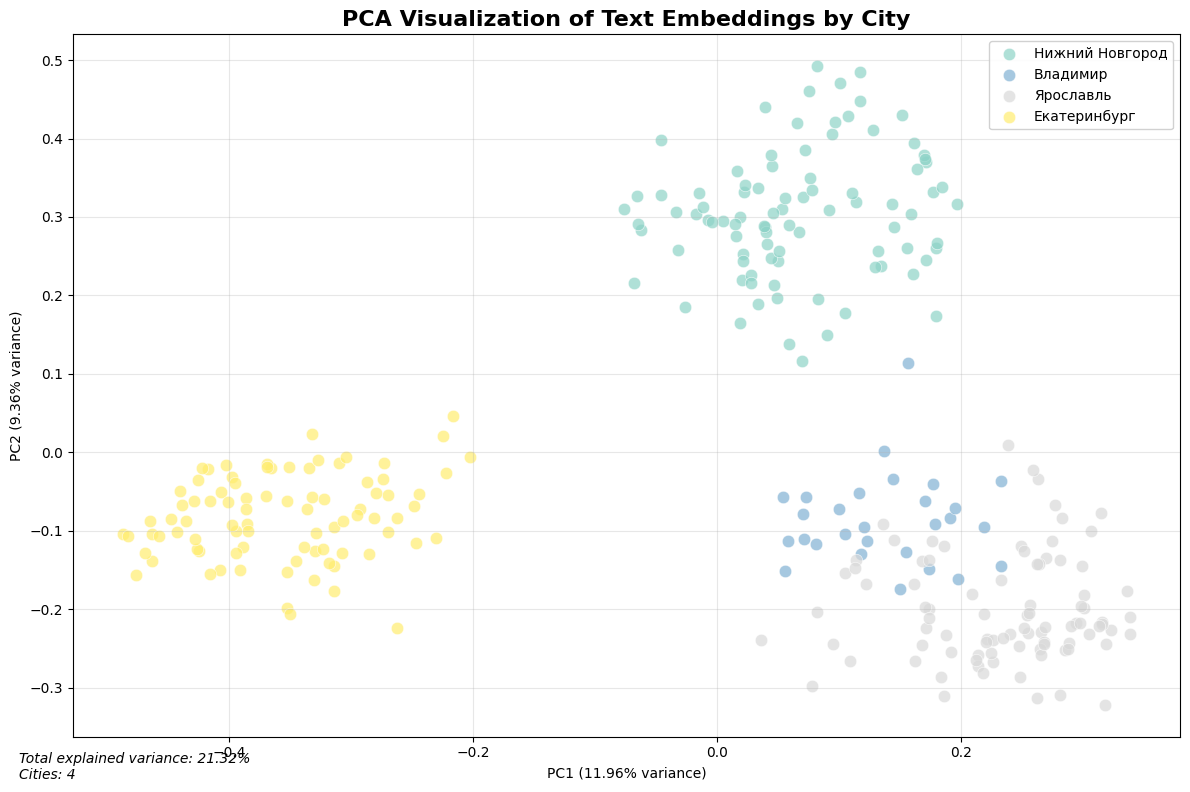


2. UMAP Visualization by City:


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


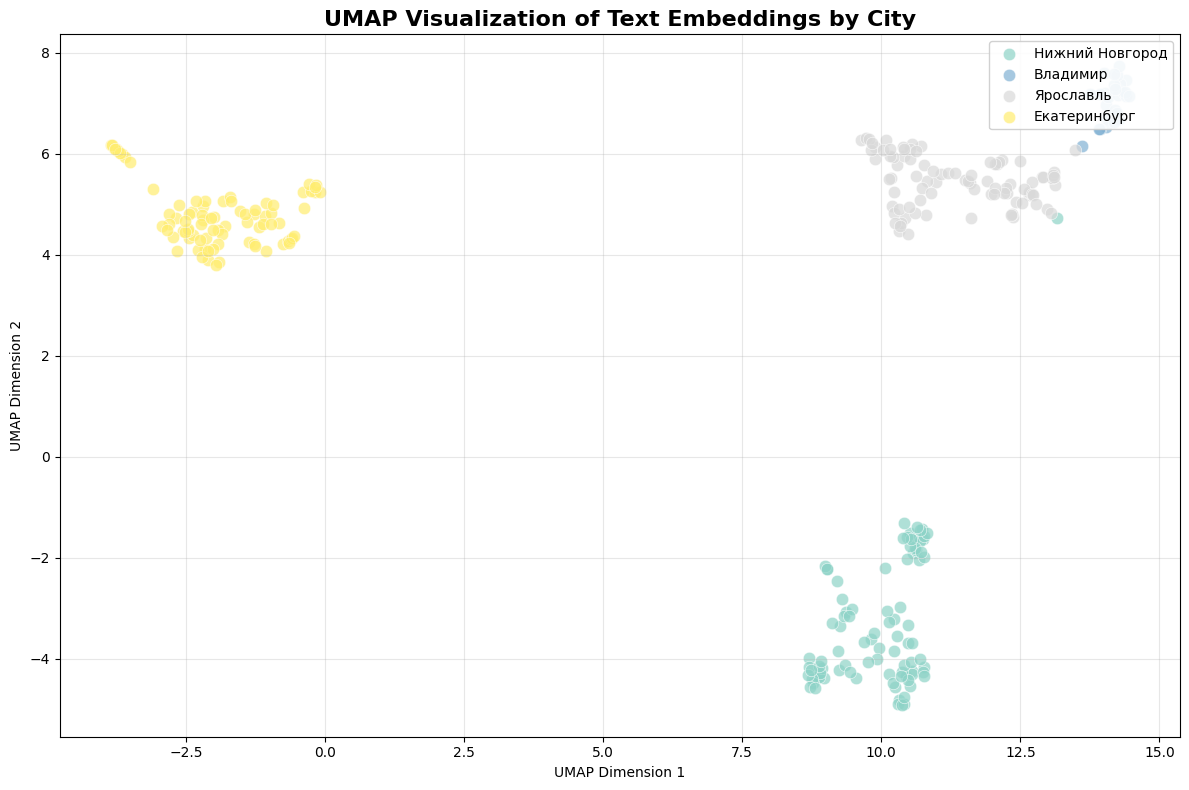


3. Comparative Visualization by City:


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


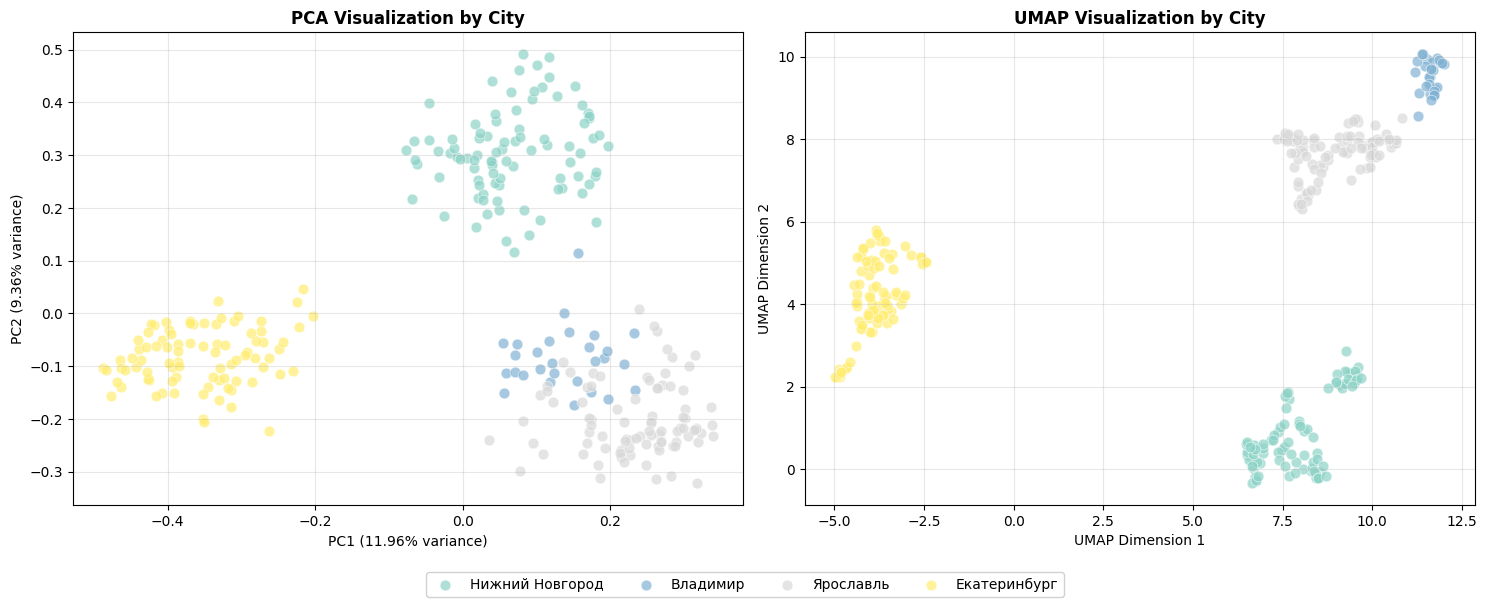

In [ ]:
import chromadb
from chromadb.utils import embedding_functions
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
import pandas as pd

class EmbeddingVisualizer:
    def __init__(self, chroma_collection, dataset):
        self.collection = chroma_collection
        self.dataset = dataset
        self.embeddings = None
        self.metadata = None
        self.documents = None

    def extract_embeddings_from_collection(self):
        """Извлекает эмбеддинги и метаданные из коллекции ChromaDB"""
        try:
            # Получаем все данные из коллекции
            results = self.collection.get(include=['embeddings', 'metadatas', 'documents'])

            self.embeddings = np.array(results['embeddings'])
            self.metadata = results['metadatas']
            self.documents = results['documents']

            print(f"Извлечено {len(self.embeddings)} эмбеддингов")
            return self.embeddings, self.metadata, self.documents
        except Exception as e:
            print(f"Ошибка при извлечении эмбеддингов: {e}")
            return None, None, None

    def get_city_categories(self):
        """Получает категории городов из dataset"""
        cities = []
        for meta in self.metadata:
            key = meta.get('source_key')
            if key and key in self.dataset:
                city = self.dataset[key].get('City', 'Unknown')
                cities.append(city)
            else:
                cities.append('Unknown')
        return cities

    def pca_visualization(self, n_components=2, figsize=(12, 8)):
        """Визуализация с помощью PCA с группировкой по городам"""
        if self.embeddings is None:
            self.extract_embeddings_from_collection()

        if self.embeddings is None:
            print("Не удалось загрузить эмбеддинги")
            return None, None

        # Применяем PCA
        pca = PCA(n_components=n_components, random_state=42)
        embeddings_2d = pca.fit_transform(self.embeddings)

        # Создаем график
        plt.figure(figsize=figsize)

        # Получаем города вместо ключей
        cities = self.get_city_categories()
        unique_cities = list(set(cities))

        print(f"Найдено городов: {unique_cities}")

        # Создаем цветовую карту для городов
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_cities)))

        # Создаем scatter plot для каждого города
        for i, city in enumerate(unique_cities):
            mask = np.array(cities) == city
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                       c=[colors[i]], label=city, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

        plt.title('PCA Visualization of Text Embeddings by City', fontsize=16, fontweight='bold')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

        # Компактная легенда
        if len(unique_cities) <= 10:  # Показываем легенду только если городов не слишком много
            plt.legend(loc='upper right', framealpha=0.9)

        plt.grid(True, alpha=0.3)

        # Добавляем информацию о объясненной дисперсии
        total_variance = sum(pca.explained_variance_ratio_)
        plt.figtext(0.02, 0.02, f'Total explained variance: {total_variance:.2%}\nCities: {len(unique_cities)}',
                   fontsize=10, style='italic')

        plt.tight_layout()
        plt.show()

        return embeddings_2d, pca

    def umap_visualization(self, n_components=2, n_neighbors=15, min_dist=0.1,
                          metric='cosine', figsize=(12, 8)):
        """Визуализация с помощью UMAP с группировкой по городам"""
        if self.embeddings is None:
            self.extract_embeddings_from_collection()

        if self.embeddings is None:
            print("Не удалось загрузить эмбеддинги")
            return None, None

        # Применяем UMAP
        reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors,
                           min_dist=min_dist, metric=metric, random_state=42)
        embeddings_2d = reducer.fit_transform(self.embeddings)

        # Создаем график
        plt.figure(figsize=figsize)

        cities = self.get_city_categories()
        unique_cities = list(set(cities))

        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_cities)))

        for i, city in enumerate(unique_cities):
            mask = np.array(cities) == city
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                       c=[colors[i]], label=city, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

        plt.title('UMAP Visualization of Text Embeddings by City', fontsize=16, fontweight='bold')
        plt.xlabel('UMAP Dimension 1')
        plt.ylabel('UMAP Dimension 2')

        # Компактная легенда
        if len(unique_cities) <= 10:
            plt.legend(loc='upper right', framealpha=0.9)

        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        return embeddings_2d, reducer

    def comparative_visualization(self, figsize=(15, 6)):
        """Сравнительная визуализация PCA и UMAP с группировкой по городам"""
        if self.embeddings is None:
            self.extract_embeddings_from_collection()

        if self.embeddings is None:
            print("Не удалось загрузить эмбеддинги")
            return None, None

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # PCA
        pca = PCA(n_components=2, random_state=42)
        pca_embeddings = pca.fit_transform(self.embeddings)

        # UMAP
        umap_reducer = umap.UMAP(n_components=2, random_state=42)
        umap_embeddings = umap_reducer.fit_transform(self.embeddings)

        cities = self.get_city_categories()
        unique_cities = list(set(cities))
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_cities)))

        # PCA plot
        for i, city in enumerate(unique_cities):
            mask = np.array(cities) == city
            ax1.scatter(pca_embeddings[mask, 0], pca_embeddings[mask, 1],
                       c=[colors[i]], label=city, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

        ax1.set_title('PCA Visualization by City', fontweight='bold')
        ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        ax1.grid(True, alpha=0.3)

        # UMAP plot
        for i, city in enumerate(unique_cities):
            mask = np.array(cities) == city
            ax2.scatter(umap_embeddings[mask, 0], umap_embeddings[mask, 1],
                       c=[colors[i]], label=city, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

        ax2.set_title('UMAP Visualization by City', fontweight='bold')
        ax2.set_xlabel('UMAP Dimension 1')
        ax2.set_ylabel('UMAP Dimension 2')
        ax2.grid(True, alpha=0.3)

        # Общая легенда только если городов не слишком много
        if len(unique_cities) <= 10:
            handles, labels = ax1.get_legend_handles_labels()
            fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05),
                      ncol=min(4, len(unique_cities)), framealpha=0.9)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15)
        plt.show()

        return pca_embeddings, umap_embeddings

    def create_city_statistics(self):
        """Создает статистику по городам"""
        cities = self.get_city_categories()
        city_counts = {}

        for city in cities:
            city_counts[city] = city_counts.get(city, 0) + 1

        print("\n=== Статистика по городам ===")
        for city, count in sorted(city_counts.items()):
            print(f"{city}: {count} объектов")

        return city_counts

# Функция для запуска визуализации
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_collection("my_rag_collection")

# Создание визуализатора с передачей dataset
visualizer = EmbeddingVisualizer(collection, dataset)  # dataset должен быть определен

# Извлечение эмбеддингов
embeddings, metadata, documents = visualizer.extract_embeddings_from_collection()

city_stats = visualizer.create_city_statistics()

print("Размерность эмбеддингов:", embeddings.shape)
print("Количество документов:", len(documents))

print("\n1. PCA Visualization by City:")
pca_embeddings, pca_model = visualizer.pca_visualization()

print("\n2. UMAP Visualization by City:")
umap_embeddings, umap_model = visualizer.umap_visualization()

print("\n3. Comparative Visualization by City:")
pca_emb, umap_emb = visualizer.comparative_visualization()

Кажется город оказывает сильное влияние на эмбеддинги раз по нему они очень хорошо разделяются на классы

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

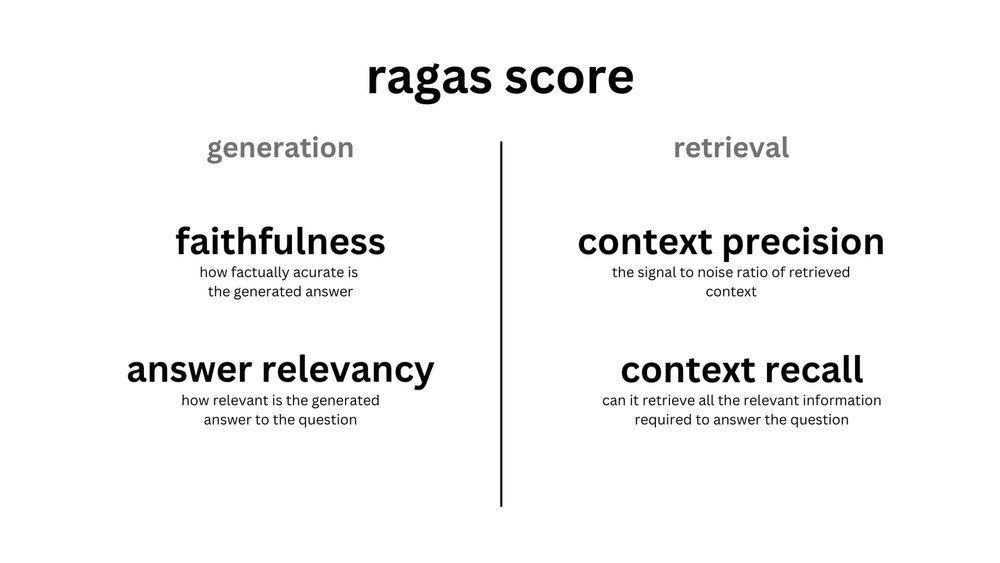

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

# Подготовка данных для RAGAS

In [9]:
dat_list = list(dataset.items())

Функция для генерации вопросов

In [92]:
from openai import OpenAI

def gen_q_a(text):
  client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
    )
  prompt = f"""
  На основе следующего текста придумай один конкретный вопрос и точный ответ на него, который полностью содержится в тексте.
  Вопрос должен быть сформулирован БЕЗ привязки к тексту!

  Примеры ПЛОХОГО вопроса:"Какое название у объекта?","Какая особенность внешнего вида здания указана в описании?","Какое название у церкви, о которой идет речь?"
  Примеры хорошего вопроса:"Какие церкви есть в нижнем новгороде" (если контекст о цервки в нижнем новгороде),"Какое название носит памятник градостроительства и архитектуры, расположенный в Нижнем Новгороде?","Какой объект в Екатеринбурге описывается как 'главная площадь'?"

  Старайся придумать текст по аналогии с примерами хороших вопросов!

  Текст: {text}

   Верни ответ в формате JSON:
   {{
     "question": "сгенерированный вопрос",
     "ground_truth": "точный ответ, основанный только на тексте"
   }}

   Убедись, что ответ можно найти непосредственно в предоставленном тексте.
   """

  chat_result = client.chat.completions.create(
  messages=[{"role": "user", "content": prompt}],
  model="google/gemini-2.5-flash-lite-preview-09-2025",
  max_tokens=300)

  response = chat_result.choices[0].message
  return response.content

Парсинг json

In [93]:
import json
import re
from typing import Dict, Any, Optional

def parse_json_from_response(response_text: str) -> Optional[Dict[str, Any]]:
    """
    Парсит JSON из текста ответа модели.

    Args:
        response_text: Текст ответа, который может содержать JSON

    Returns:
        Dict с распарсенными данными или None, если парсинг не удался
    """
    try:
        # Сначала пробуем найти JSON объект в тексте
        json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
        if json_match:
            json_str = json_match.group()
            return json.loads(json_str)

        # Если не нашли полный JSON, пробуем парсить весь текст как JSON
        return json.loads(response_text)

    except json.JSONDecodeError:
        # Если стандартный парсинг не сработал, пытаемся извлечь данные другими способами
        return None

RAG с выводом контекста и цикл для генерации набора данных для расчета метрикк

In [94]:
import random

def mod_rag_fixed(query):
    results = collection.query(
        query_texts=[query],
        n_results=4
    )
    contexts = results['documents'][0]


    context_text = "\n".join(contexts)

    # Генерация ответа
    llm_client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY,
        default_headers={"HTTP-Referer": "http://localhost:3000"}
    )

    response = llm_client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{
            "role": "user",
            "content": f"Ответь на вопрос: {query}\n\nКонтекст: {context_text}"
        }]
    )

    return response.choices[0].message.content, contexts


RAGAS = {}
num_samples = 300

for i in tqdm(range(num_samples)):
    tf = True
    while tf:
        random_data = random.choice(dat_list)
        ans = gen_q_a(random_data[1]['all_data'])
        dict_data = parse_json_from_response(ans)
        if dict_data is not None:
            tf = False
            answer, contexts_list = mod_rag_fixed(dict_data['question'])
            RAGAS[i] = {
                'question': dict_data['question'],
                'ground_truth': dict_data['ground_truth'],
                'answer': answer,
                'contexts': contexts_list
            }

100%|██████████| 300/300 [10:12<00:00,  2.04s/it]


In [95]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.tokenize import sent_tokenize
from typing import List, Dict
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# RAGAS метрики

In [96]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.tokenize import sent_tokenize
from typing import List, Dict
import logging
import re

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class RAGASEvaluator:
    def __init__(self, model_name: str = "sentence-transformers/all-MiniLM-L6-v2"):
        logger.info(f"Инициализация модели: {model_name}")
        self.model = SentenceTransformer(model_name)

    def evaluate_dataset(self, dataset: Dict) -> Dict:
        """Оценка с семантическим сравнением"""
        logger.info(f"Начало оценки датасета, samples: {len(dataset)}")

        metrics = {
            'faithfulness': [],
            'answer_relevancy': [],
            'context_recall': [],
            'context_precision': [],
            'answer_similarity': [],
            'answer_correctness': [],
            'retrieval_precision': []
        }

        for i, (sample_id, sample) in enumerate(dataset.items()):
            logger.info(f"Обработка sample {i+1}/{len(dataset)}")

            question = sample['question']
            ground_truth = sample['ground_truth']
            answer = sample['answer']
            contexts = sample['contexts']

            # Исправленные метрики
            faith = self._calculate_faithfulness_fixed(answer, contexts, ground_truth, sample_id)
            rel = self._calculate_answer_relevancy(question, answer, sample_id)
            recall = self._calculate_context_recall_fixed(ground_truth, contexts, sample_id)
            prec = self._calculate_context_precision(question, contexts, ground_truth, sample_id)
            sim = self._calculate_semantic_similarity(answer, ground_truth, sample_id)
            retrieval_prec = self._calculate_retrieval_precision(question, contexts, ground_truth, sample_id)

            correctness = 0.5 * faith + 0.5 * sim

            metrics['faithfulness'].append(faith)
            metrics['answer_relevancy'].append(rel)
            metrics['context_recall'].append(recall)
            metrics['context_precision'].append(prec)
            metrics['answer_similarity'].append(sim)
            metrics['answer_correctness'].append(correctness)
            metrics['retrieval_precision'].append(retrieval_prec)

        final_metrics = {metric: np.mean(scores) for metric, scores in metrics.items()}
        final_metrics['total_samples'] = len(dataset)

        logger.info("Оценка завершена")
        return final_metrics

    def _calculate_faithfulness_fixed(self, answer: str, contexts: List[str], ground_truth: str, sample_id: str) -> float:
        """Исправленный Faithfulness: проверяет семантическую согласованность"""
        logger.debug(f"Sample {sample_id}: вычисление Faithfulness (исправленный)")

        if not answer or not contexts:
            return 0.0

        answer_embed = self.model.encode([answer])
        contexts_embed = self.model.encode([" ".join(contexts)])
        gt_embed = self.model.encode([ground_truth])

        # Сходство ответа с контекстами
        answer_context_sim = cosine_similarity(answer_embed, contexts_embed)[0][0]

        # Сходство ответа с ground truth
        answer_gt_sim = cosine_similarity(answer_embed, gt_embed)[0][0]

        # Faithfulness как комбинация обеих мер
        faithfulness_score = 0.7 * answer_context_sim + 0.3 * answer_gt_sim

        logger.debug(f"Sample {sample_id}: Faithfulness = {faithfulness_score:.3f} "
                    f"(answer-context: {answer_context_sim:.3f}, answer-gt: {answer_gt_sim:.3f})")

        return max(0.0, min(1.0, faithfulness_score))

    def _calculate_context_recall_fixed(self, ground_truth: str, contexts: List[str], sample_id: str) -> float:
        """Исправленный Context Recall: семантическое сходство вместо точного совпадения"""
        logger.debug(f"Sample {sample_id}: вычисление Context Recall (исправленный)")

        if not ground_truth or not contexts:
            return 0.0

        # Эмбеддинг ground truth
        gt_embed = self.model.encode([ground_truth])

        # Эмбеддинги всех контекстов
        context_embeds = self.model.encode(contexts)

        # Находим максимальное сходство между ground truth и любым контекстом
        max_similarity = 0.0
        for i, context_embed in enumerate(context_embeds):
            similarity = cosine_similarity(gt_embed, [context_embed])[0][0]
            if similarity > max_similarity:
                max_similarity = similarity
                logger.debug(f"Sample {sample_id}: контекст {i} сходство с GT: {similarity:.3f}")

        # Context Recall как максимальное сходство (можно также использовать среднее)
        recall_score = max_similarity

        logger.debug(f"Sample {sample_id}: Context Recall = {recall_score:.3f}")

        return max(0.0, min(1.0, recall_score))

    def _calculate_answer_relevancy(self, question: str, answer: str, sample_id: str) -> float:
        """Answer Relevancy: семантическое сходство вопроса и ответа"""
        if not question or not answer:
            return 0.0

        question_embed = self.model.encode([question])
        answer_embed = self.model.encode([answer])

        similarity = cosine_similarity(question_embed, answer_embed)[0][0]
        logger.debug(f"Sample {sample_id}: Answer Relevancy = {similarity:.3f}")

        return max(0.0, min(1.0, similarity))

    def _calculate_context_precision(self, question: str, contexts: List[str], ground_truth: str, sample_id: str, k: int = 3) -> float:
        """Context Precision: точность top-k контекстов"""
        if not contexts:
            return 0.0

        # Эмбеддинги вопроса и ground truth
        question_embed = self.model.encode([question])
        gt_embed = self.model.encode([ground_truth])

        # Оцениваем релевантность каждого контекста
        relevancy_scores = []
        for j, context in enumerate(contexts[:k]):
            context_embed = self.model.encode([context])

            # Релевантность вопросу
            q_relevancy = cosine_similarity(question_embed, context_embed)[0][0]
            # Релевантность ground truth
            gt_relevancy = cosine_similarity(gt_embed, context_embed)[0][0]

            combined_score = (q_relevancy + gt_relevancy) / 2
            relevancy_scores.append(combined_score)

            logger.debug(f"Sample {sample_id}: контекст {j+1} - релевантность={combined_score:.3f}")

        # Precision@k
        threshold = 0.5
        relevant_count = sum(1 for score in relevancy_scores if score > threshold)
        precision_score = relevant_count / len(relevancy_scores) if relevancy_scores else 0.0

        logger.debug(f"Sample {sample_id}: Context Precision = {relevant_count}/{len(relevancy_scores)} = {precision_score:.3f}")

        return precision_score

    def _calculate_semantic_similarity(self, answer: str, ground_truth: str, sample_id: str) -> float:
        """Answer Semantic Similarity: семантическое сходство ответа и ground truth"""
        if not answer or not ground_truth:
            return 0.0

        answer_embed = self.model.encode([answer])
        gt_embed = self.model.encode([ground_truth])

        similarity = cosine_similarity(answer_embed, gt_embed)[0][0]
        logger.debug(f"Sample {sample_id}: Answer Semantic Similarity = {similarity:.3f}")

        return max(0.0, min(1.0, similarity))

    def _calculate_retrieval_precision(self, question: str, contexts: List[str], ground_truth: str, sample_id: str) -> float:
        """Retrieval Precision: оценка релевантности контекстов"""
        if not contexts:
            return 0.0

        question_embed = self.model.encode([question])
        gt_embed = self.model.encode([ground_truth])

        relevant_contexts = 0
        for j, context in enumerate(contexts):
            context_embed = self.model.encode([context])

            # Релевантность вопросу
            q_similarity = cosine_similarity(question_embed, context_embed)[0][0]
            # Релевантность ground truth
            gt_similarity = cosine_similarity(gt_embed, context_embed)[0][0]

            combined_similarity = (q_similarity + gt_similarity) / 2

            if combined_similarity > 0.5:
                relevant_contexts += 1
                logger.debug(f"Sample {sample_id}: контекст {j+1} релевантен (similarity={combined_similarity:.3f})")

        retrieval_precision = relevant_contexts / len(contexts) if contexts else 0.0
        logger.debug(f"Sample {sample_id}: Retrieval Precision = {relevant_contexts}/{len(contexts)} = {retrieval_precision:.3f}")

        return retrieval_precision

# Затем переоцените весь датасет
def reevaluate_dataset(dataset: Dict):
    """Переоценка всего датасета с исправленными метриками"""
    evaluator = RAGASEvaluator()
    return evaluator.evaluate_dataset(dataset)

# Перезапустите оценку
new_results = reevaluate_dataset(RAGAS)
print("РЕЗУЛЬТАТЫ:")
for metric, score in new_results.items():
    if metric != 'total_samples':
        print(f"{metric}: {score:.3f}")

РЕЗУЛЬТАТЫ:
faithfulness: 0.488
answer_relevancy: 0.768
context_recall: 0.500
context_precision: 0.123
answer_similarity: 0.630
answer_correctness: 0.559
retrieval_precision: 0.102


# Результаты

In [97]:
for metric, score in new_results.items():
    if metric != 'total_samples':
        print(f"{metric}: {score:.3f}")

faithfulness: 0.488
answer_relevancy: 0.768
context_recall: 0.500
context_precision: 0.123
answer_similarity: 0.630
answer_correctness: 0.559
retrieval_precision: 0.102


Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

**Я выше реализовал retrieval_precision, так что уже есть :)**

Если же оценивать RAG, то моя система слишком упрощенная с большим выводом лишнего контекста. Скорее всего можно поднять точность если поработать с параметрами поиска, но мне уже давно больше хочется разобраться с lightRAG и graphRAG. Они бы дали более удачную точность :)

Также есть проблема с вопросами. Т.к. в тексте мало информации LLM вечно задает вопросы привязываясь к тексту напрямую. Пример ниже

In [143]:
RAGAS[1]

{'question': 'Как часто описывают объект как церковь?',
 'ground_truth': 'The destination is a large white building, often described as a church',
 'answer': 'В тексте описывают объект как церковь четыре раза.',
 'contexts': ['Name: Владимирская церковь \n City: Ярославль \n Description: Владимирская церковь на Божедомке \n WikiData: Q4113263 \n Longitude: 39.852306 \n Latitude: 57.625523 \n Description of appearance: This destination primarily features a white church, often characterized by blue domes, a blue roof, or prominent steeples and towers. Views can include elements like fences, trees, snowy settings, or clock towers.',
  'Name: Троицкая церковь \n City: Владимир \n Description: Троицкая церковь \n WikiData: Q9187382 \n Longitude: 40.396076 \n Latitude: 56.126453 \n Description of appearance: This location features a large red brick church, often described as having a clock tower or steeple. Views can include surrounding streets, other city elements like a river, and sometime

Бороться с таким сложно, а на метрики оно к сожалению влияет